Instalações da Biblioteca   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.colors as mcolors

Os dados são carregados e formatados

In [2]:
#carregar dado
df = pd.DataFrame(pd.read_csv('dados_2025.csv'))
# Limpeza de dados 
#Arrumar valor de transação
df['valorTransacao'] = pd.to_numeric(df['valorTransacao']. 
                        str.replace('.', ''). #retira o . da casa de milhares
                        str.replace(',', '.'). #substitui , de centavos para .
                        str.replace('- ', '-') #substitui
)
df['dataTransacao'] = pd.to_datetime(df['dataTransacao']. 
                        str.replace('Sem informação', '01/01/2025'),
                        dayfirst=True
)
df = df[df['dataTransacao'].dt.year == 2025]
df = df.drop_duplicates()

Agrupamento por estabelecimento, Ministério e Portador

In [3]:
sum_estabe = df.groupby("estabelecimento.nome")["valorTransacao"].sum().sort_values(ascending=False)
sum_orgao = df.groupby("unidadeGestora.orgaoMaximo.nome")["valorTransacao"].sum().sort_values(ascending=False)
sum_pessoa = df.groupby("portador.nome")["valorTransacao"].sum().sort_values(ascending=False)

resum = {
    "Numero de Transações": len(df),
    "Valor Total gasto": f"R$ {df['valorTransacao'].sum():.2f}",
    "Valor médio por transação": f"R$ {df['valorTransacao'].mean():.2f}",
    "Maior Transação": f"R$ {df['valorTransacao'].max():.2f}",
    "Menor Transação": f"R$ {df['valorTransacao'].min():.2f}"
}


In [4]:
print("----- Resumo de Valores -----" )
for k, v in resum.items():
    print(f"{k}: {v:,.2f}" if isinstance(v, float) else f"{k}: {v}")
print("---------------------")
print(f"Top 5 Estabelecimentos frequentes: {sum_estabe.head(5)}")
print(f"Top 5 Orgãos que mais gastaram: {sum_orgao.head(5)}")

----- Resumo de Valores -----
Numero de Transações: 143361
Valor Total gasto: R$ 367570366.68
Valor médio por transação: R$ 2563.95
Maior Transação: R$ 8265877.90
Menor Transação: R$ -4338459.62
---------------------
Top 5 Estabelecimentos frequentes: estabelecimento.nome
Sigiloso                                  32700647.39
BURITI DISTRIBUIDORA DE ALIMENTOS LTDA    11048860.88
NAO SE APLICA                              8329772.61
KOMAK MAQUINAS E EQUIPAMENTOS LTDA         8265877.90
E. I. DIAS LTDA                            7436437.91
Name: valorTransacao, dtype: float64
Top 5 Orgãos que mais gastaram: unidadeGestora.orgaoMaximo.nome
Ministério da Integração e do Desenvolvimento Regional    2.541907e+08
Ministério da Justiça e Segurança Pública                 3.287785e+07
Sem informação                                            1.818356e+07
Ministério da Defesa                                      1.623622e+07
Ministério da Educação                                    1.332340e+07
N

In [5]:
#formatar valor nos gráficos
def formatar_moeda(x,pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}Bi'
    elif x >= 1e6:
        return f'{x/1e6:.0f}Mi'
    elif x >= 1e3:
        return f'{x/1e3:.0f}k'
    else:
        return '' 


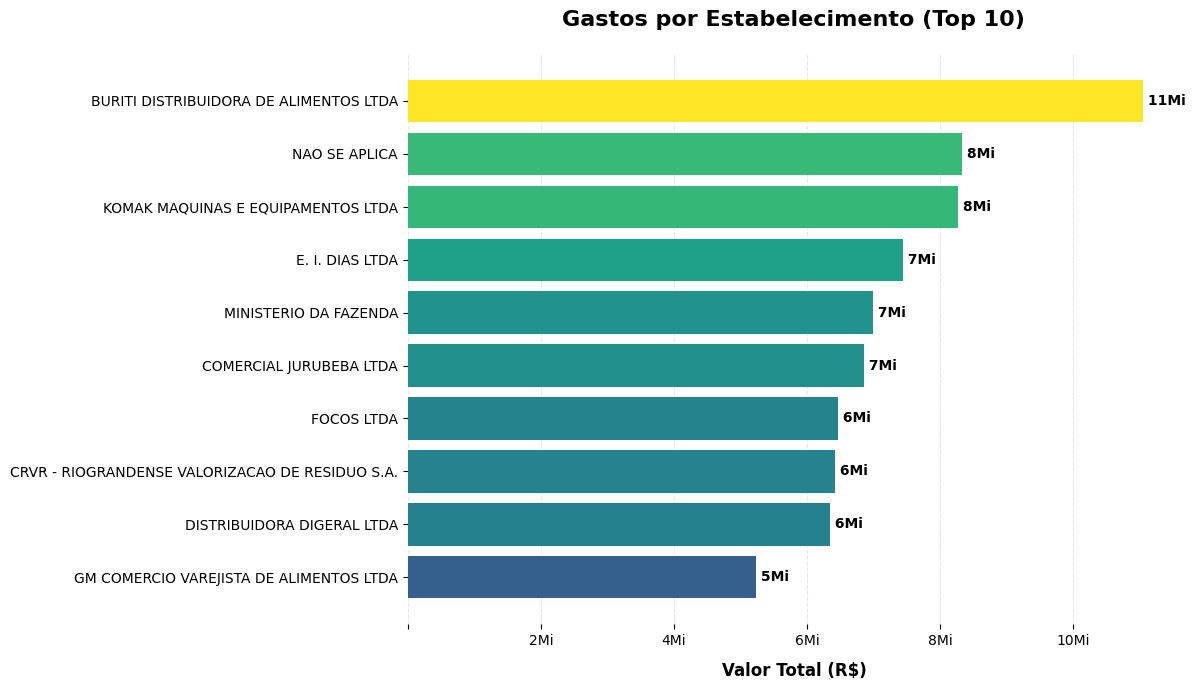

In [12]:
mask_valido = ~sum_estabe.index.str.contains('sigi', case=False, na=False)
top_estabe = sum_estabe[mask_valido].head(10)
plt.figure(figsize=(12,7))
reverse = top_estabe.values[::-1]
norm = plt.Normalize(vmin=min(reverse), vmax=max(reverse))
cores_barras = [plt.cm.viridis(0.3 + 0.7 * norm(val)) for val in reverse]
plt.barh(top_estabe.index[::-1], reverse,color=cores_barras, edgecolor='none', zorder=3)
plt.xlabel("Valor Total (R$)",fontsize=12, fontweight='bold', labelpad=10)
plt.title("Gastos por Estabelecimento (Top 10)",fontsize=16, fontweight='bold', pad=20)
#formata os valores
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(formatar_moeda))
# Adiciona os textos nas barras
for i, valor in enumerate(reverse):
    texto = formatar_moeda(valor, [])
    posicao_x = min(valor, 1e9) 
    plt.text(posicao_x, i, f' {texto}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
plt.box(False)
plt.tight_layout()
plt.savefig('assets/Gastos_estabe.png')
plt.show()

In [7]:
# alterar os nomes dos orgãos
def shorten(name):
    replacements = {
        'Ministério': 'Min.',
        'Presidência da República': 'Presidência',
        'Banco Central do Brasil - Orçamento Fiscal e Seguridade Social': 'Banco Central',
    }
    for k, v in replacements.items():
        name = name.replace(k, v)
    return name[:55]


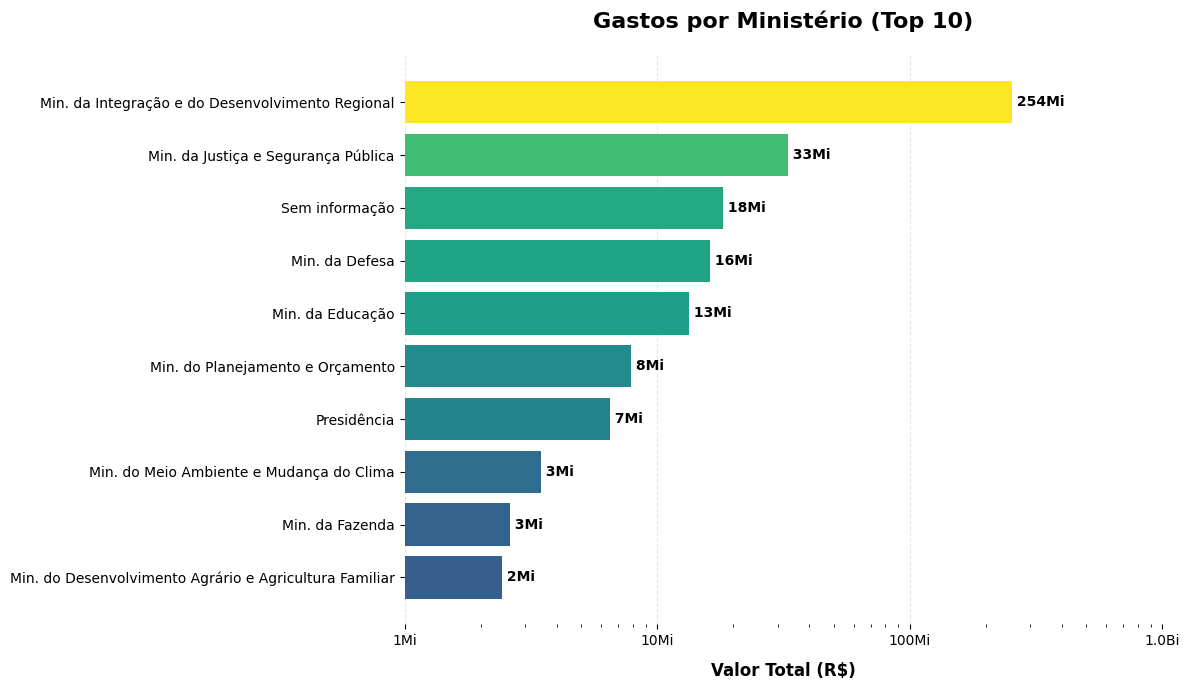

In [13]:
#gastos por instituição
top_orgao = sum_orgao.head(10)
plt.figure(figsize=(12,7))
reverse_org = top_orgao.values[::-1]
top_orgao.index = [shorten(n) for n in top_orgao.index]
norm_org = mcolors.LogNorm(vmax=max(reverse_org), vmin=min(reverse_org))
cores_org = [plt.cm.viridis(0.3 + 0.7 * norm_org(val)) for val in reverse_org]
plt.barh(top_orgao.index[::-1], reverse_org, color=cores_org, edgecolor='none', zorder=3)
plt.xlim(left=1e5, right=1e9)
plt.xscale('log')
plt.xlabel("Valor Total (R$)",fontsize=12, fontweight='bold', labelpad=10)
plt.title("Gastos por Ministério (Top 10)",fontsize=16, fontweight='bold', pad=20)
locais, label = plt.xticks()
plt.box(False)
plt.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(formatar_moeda))
plt.xlim(left=1e6, right=1e9)
# Adiciona os textos nas barras
for i, valor in enumerate(reverse_org):
    texto = formatar_moeda(valor,[])
    posicao_x = min(valor, 1e9) 
    plt.text(posicao_x, i, f' {texto}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('assets/Gastos_orgao.png')
plt.show()

In [9]:
mask = sum_estabe.index.str.contains('sigiloso|sem info', case=False, na=False)
apenas_sigilo = sum_estabe.iloc[mask].sum()
valor_total = df['valorTransacao'].sum()
valor_declarado = valor_total - apenas_sigilo
label_pie = ['Valores Declarados', 'Valores Sigilosos']
valor_pie = [valor_declarado, apenas_sigilo]

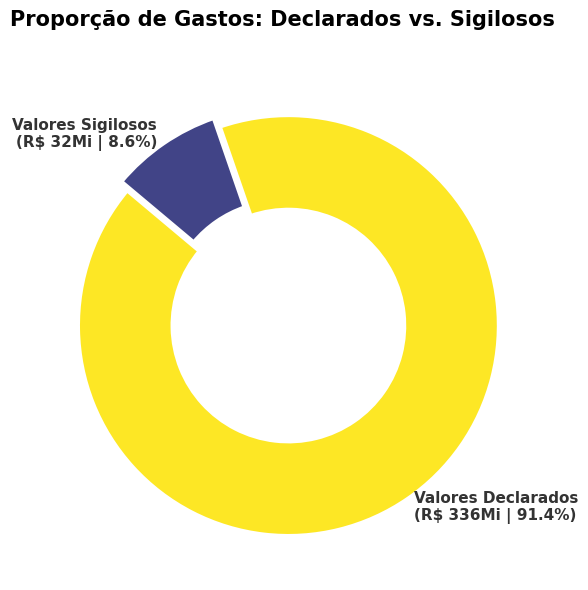

In [14]:
plt.figure(figsize=(9, 6))
novos_labels = []
for rotulo, valor in zip(label_pie, valor_pie):
    pct = (valor / sum(valor_pie)) * 100
    valor_fmt = formatar_moeda(valor,[])
    novos_labels.append(f'{rotulo}\n(R$ {valor_fmt} | {pct:.1f}%)')

afastamento = (0.05, 0) 
cores = ['#FDE725', '#414487']  #Contraste viridis
plt.pie(valor_pie, 
        labels=novos_labels, 
        startangle=140, 
        explode=afastamento, 
        colors=cores,
        labeldistance=1.05,
        textprops={'fontsize': 11, 'fontweight': 'bold', 'color': '#333333'},
        wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 3})
plt.title("Proporção de Gastos: Declarados vs. Sigilosos", fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('assets/Gastos_sigilo.png')
plt.show()
